# Sentinel-1 SAR over the Denman Glacier

Define the area of interest, search the GA DEA STAC for Sentinel-1 Normalised Radar
Backscatter (NRB, HH), look at the acquisition timeline, load the scenes into an xarray
and plot a speckle-filtered monthly backscatter mosaic.

**Note** - Data is stored as individual sentinel-1 bursts, rather than scenes, as bursts are the repeatable unit captured unit by the satellite. These can be combined and merged as desired by the user.

Coverage can be viewed here - https://explorer.dev.dea.ga.gov.au/products/ga_s1_nrb_iw_hh_1

In [2]:
import os

# Use the environment's own PROJ/GDAL data, not any inherited paths
for _var in ("PROJ_LIB", "PROJ_DATA", "GDAL_DATA"):
    os.environ.pop(_var, None)

import numpy as np
import pandas as pd
import shapely
import matplotlib.pyplot as plt
from pystac_client import Client
from odc.geo import BoundingBox
from odc.stac import load, configure_s3_access

from de_sar_demo.speckle_filters import lee_filter_xr

## Area of interest

In [3]:
# Denman Glacier
aoi_bbox = BoundingBox(left=98.0, bottom=-67.5, right=101.5, top=-65.5, crs="EPSG:4326")
aoi_shape = shapely.geometry.shape(aoi_bbox.polygon)
start_date, end_date = "2025-01-01", "2026-01-01"

## Search STAC

- NOTE - the dev stac api can be slow -> reduce time range or area to speed up the load

In [4]:
# HH is the dominant polarisation over Antarctica, very little HH+HV is available for IW mode
COLLECTION = ["ga_s1_nrb_iw_hh_1"]  # "ga_s1_nrb_iw_hh_hv_1"

stac_client = Client.open("https://explorer.dev.dea.ga.gov.au/stac")
configure_s3_access(cloud_defaults=True, aws_unsigned=True)

items = stac_client.search(
    collections=[COLLECTION],
    datetime=f"{start_date}/{end_date}",
    intersects=aoi_shape,
).item_collection()

print(f"Found {len(items)} items")

Found 2515 items


### Show the metadata and assets that can be loaded
- We will load in the hh_gamma0 asset, but there are other layers (e.g. oa_incidence_angle) that may be of use

In [5]:
items[0]

<Item id=959e36b0-2780-505b-8f1f-dc1e6aca1265>

## Acquisition timeline

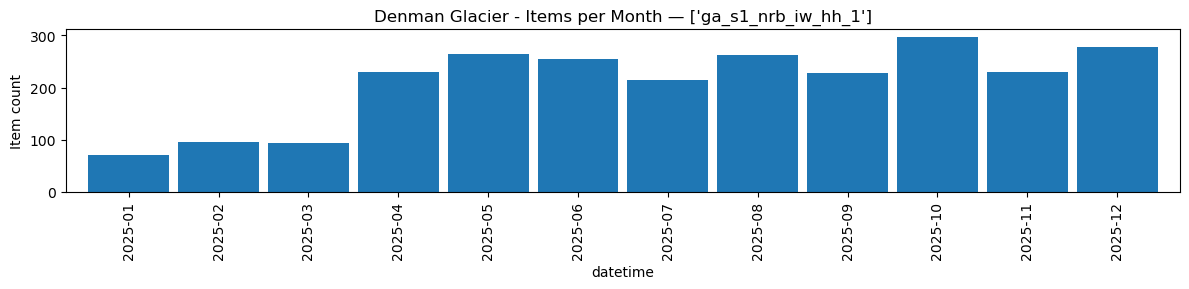

In [6]:
# Extract datetimes from items
dates = [pd.to_datetime(item.datetime) for item in items]

df = pd.DataFrame({"datetime": dates})
df.set_index("datetime", inplace=True)
counts = df.resample("ME").size()  # monthly counts

fig, ax = plt.subplots(figsize=(12, 3))
counts.plot(kind="bar", ax=ax, width=0.9)
ax.set_ylabel("Item count")
ax.set_title(f"Denman Glacier - Items per Month — {COLLECTION}")

# Label every tick as YYYY-MM
labels = counts.index.strftime("%Y-%m")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(labels, rotation=90)

plt.tight_layout()
plt.show()

## Load

In [7]:
ds = load(
    items,
    bands=["hh_gamma0"],
    geopolygon=aoi_shape,
    crs="EPSG:3031",            # Antarctic Polar Stereographic
    resolution=200,             # reduce resolution to speed up load and plot
    groupby="solar_day",        # combine bursts captured on the same day
    chunks={},
).sortby("time")

print(f"{ds.sizes['time']} time steps")

104 time steps


## Monthly mosaic

Lee-filtered HH backscatter in dB, averaged by calendar month.

/Users/alexbradley/Documents/AlexsComputer/GA/DEAntarctica/Projects/de-sar-sample-data/.pixi/envs/default/lib/python3.13/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


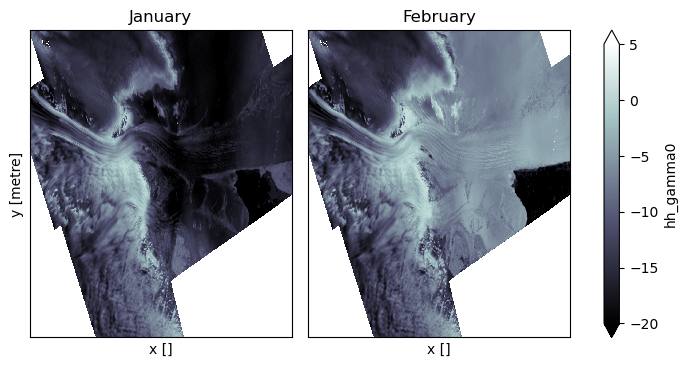

In [8]:
months_to_plot = [1, 2]  # e.g. January and Feb

# apply a lee filter and take the mean monthly value of overlapping bursts
db = 10 * np.log10(lee_filter_xr(ds.hh_gamma0, size=5))
db_subset = db.sel(time=db["time.month"].isin(months_to_plot))
monthly = db_subset.groupby("time.month").mean()

grid = monthly.plot.imshow(
    col="month", col_wrap=2, cmap="bone", vmin=-20, vmax=5,
    figsize=(8, 4),
)
for ax, m in zip(grid.axes.flat, monthly["month"].values):
    ax.set_title(pd.Timestamp(2000, int(m), 1).strftime("%B"))
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()